In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('/content/drive/MyDrive/indian_cities.csv')

In [ ]:
data

,Rank,City,State,Population,Metro_Population,Sexratio,Literacy
0,1,Mumbai,Maharashtra,12442373,18414288,853,89.73
1,2,Delhi,Delhi,11034555,16314838,876,87.59
2,3,Bangalore,Karnataka,8443675,8499399,923,88.71
3,4,Hyderabad,Andhra Pradesh,6731790,7749334,955,83.26
4,5,Ahmedabad,Gujarat,5577940,6352254,898,88.29
...,...,...,...,...,...,...,...
493,494,Gangtok,Sikkim,100286,100286,912,89.33
494,495,Datia,Madhya Pradesh,100284,100284,900,80.56
495,496,Nagda,Madhya Pradesh,100039,100039,947,80.71
496,497,Banswara,Rajasthan,99969,101177,960,85.72


tabel diatas menjelaskan terkait kota di india, data tersebut ditampilkan berupa city (kota) state (bagian/propinsi) populasi , metro populasi sexratio dan literacy yang dilakukan perangkingan berdasarkan populasi dari kota bisa menggunakan intruksi
data = pd.read_csv('/content/drive/MyDrive/indian_cities.csv')

In [6]:
data.dtypes

,0
Rank,int64
City,object
State,object
Population,int64
Metro_Population,int64
Sexratio,int64
Literacy,float64


Jenis data (data types) dalam DataFrame berdasarkan output dari sel, sehingga dapat kita rangkum sebagai berikut:

    Rank, Population, Metro_Population, dan Sexratio bertipe int64 (bilangan bulat/integer).

    City dan State bertipe object (biasanya berupa teks/string).

    Literacy bertipe float64 (bilangan desimal/floating-point).

Hal ini menunjukkan bahwa kolom numerik telah diidentifikasi dengan benar sebagai integer atau float, dan kolom kategorikal diidentifikasi sebagai objek.

In [7]:
data.isnull()

,Rank,City,State,Population,Metro_Population,Sexratio,Literacy
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
493,False,False,False,False,False,False,False
494,False,False,False,False,False,False,False
495,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False


Metode data isnull digunakan untuk mendeteksi nilai yang hilang atau 'null' (sering juga disebut 'NaN' atau 'None') dalam setiap elemen DataFrame. Metode ini akan mengembalikan DataFrame baru dengan ukuran yang sama, di mana setiap nilai adalah True jika data asli adalah null, dan False jika data tersebut ada.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              498 non-null    int64  
 1   City              498 non-null    object 
 2   State             498 non-null    object 
 3   Population        498 non-null    int64  
 4   Metro_Population  498 non-null    int64  
 5   Sexratio          498 non-null    int64  
 6   Literacy          498 non-null    float64
dtypes: float64(1), int64(4), object(2)
memory usage: 27.4+ KB


Metode data.info memberikan ringkasan singkat dari DataFrame, yang sangat berguna untuk mendapatkan gambaran cepat tentang dataset. Berdasarkan output dari sel

In [10]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rank,498.0,249.500000,1.439045e+02,1.00,125.250,249.50,373.7500,498.00
Population,498.0,449803.008032,1.029319e+06,98916.00,125642.000,184105.00,349596.0000,12442373.00
Metro_Population,498.0,555603.297189,1.501008e+06,98916.00,138462.500,204806.00,410386.2500,18414288.00
Sexratio,498.0,932.903614,5.539232e+01,709.00,894.250,925.00,975.5000,1093.00
Literacy,498.0,84.261004,6.306394e+00,48.28,80.945,85.18,88.6125,98.36


Berikut adalah penjelasan dari setiap statistik yang disajikan:

    count: Jumlah nilai non-null dalam setiap kolom. Ini menunjukkan bahwa semua kolom numerik memiliki 498 entri, yang berarti tidak ada nilai yang hilang.
    mean: Rata-rata dari nilai-nilai dalam kolom.
        Misalnya, rata-rata Population adalah sekitar 449,803.
    std: Standar deviasi, yang mengukur seberapa tersebar nilai-nilai dalam kolom dari rata-ratanya.
        Standar deviasi yang tinggi untuk Population (sekitar 1 juta) menunjukkan variasi yang besar dalam ukuran populasi antar kota.
    min: Nilai minimum dalam kolom.
    25% (Q1): Kuartil pertama, yang berarti 25% data berada di bawah nilai ini.
    50% (Median): Median atau kuartil kedua, yang berarti 50% data berada di bawah nilai ini. Ini seringkali lebih robust terhadap outlier dibandingkan rata-rata.
    75% (Q3): Kuartil ketiga, yang berarti 75% data berada di bawah nilai ini.
    max: Nilai maksimum dalam kolom.

Dari output ini, diperoleh tentang distribusi data, seperti berikut ini:

    Population: Memiliki rentang yang sangat luas (dari 98,916 hingga 12,442,373), menunjukkan adanya kota-kota besar dan kecil. Rata-rata populasi jauh lebih tinggi daripada median, mengindikasikan adanya beberapa kota dengan populasi sangat besar yang menarik rata-rata ke atas.
    Sexratio: Rentangnya dari 709 hingga 1093, dengan rata-rata 932.9, menunjukkan bahwa secara umum ada lebih banyak pria daripada wanita di sebagian besar kota (rasio di bawah 1000).
    Literacy: Rentangnya dari 48.28% hingga 98.36%, dengan rata-rata 84.26%, menunjukkan tingkat literasi yang bervariasi tetapi umumnya tinggi di kota-kota yang tercakup dalam dataset.



In [11]:
print(str(data.index))

RangeIndex(start=0, stop=498, step=1)



Instruksi print(str(data.index)) pada dasarnya meminta untuk menampilkan representasi string dari indeks DataFrame data.

Berikut penjelasannya:

    data.index: Dalam pandas DataFrame, index adalah label untuk baris-baris data. Secara default, jika Anda tidak menentukan indeks kustom, pandas akan membuat RangeIndex yang merupakan urutan bilangan bulat dari 0 hingga n-1 (di mana n adalah jumlah baris).

    str(data.index): Fungsi str() mengonversi objek data.index menjadi representasi string-nya. Ini berguna jika Anda ingin melihat indeks dalam format yang dapat dicetak atau disimpan sebagai teks.

    print(...): Fungsi print() kemudian menampilkan representasi string tersebut ke konsol

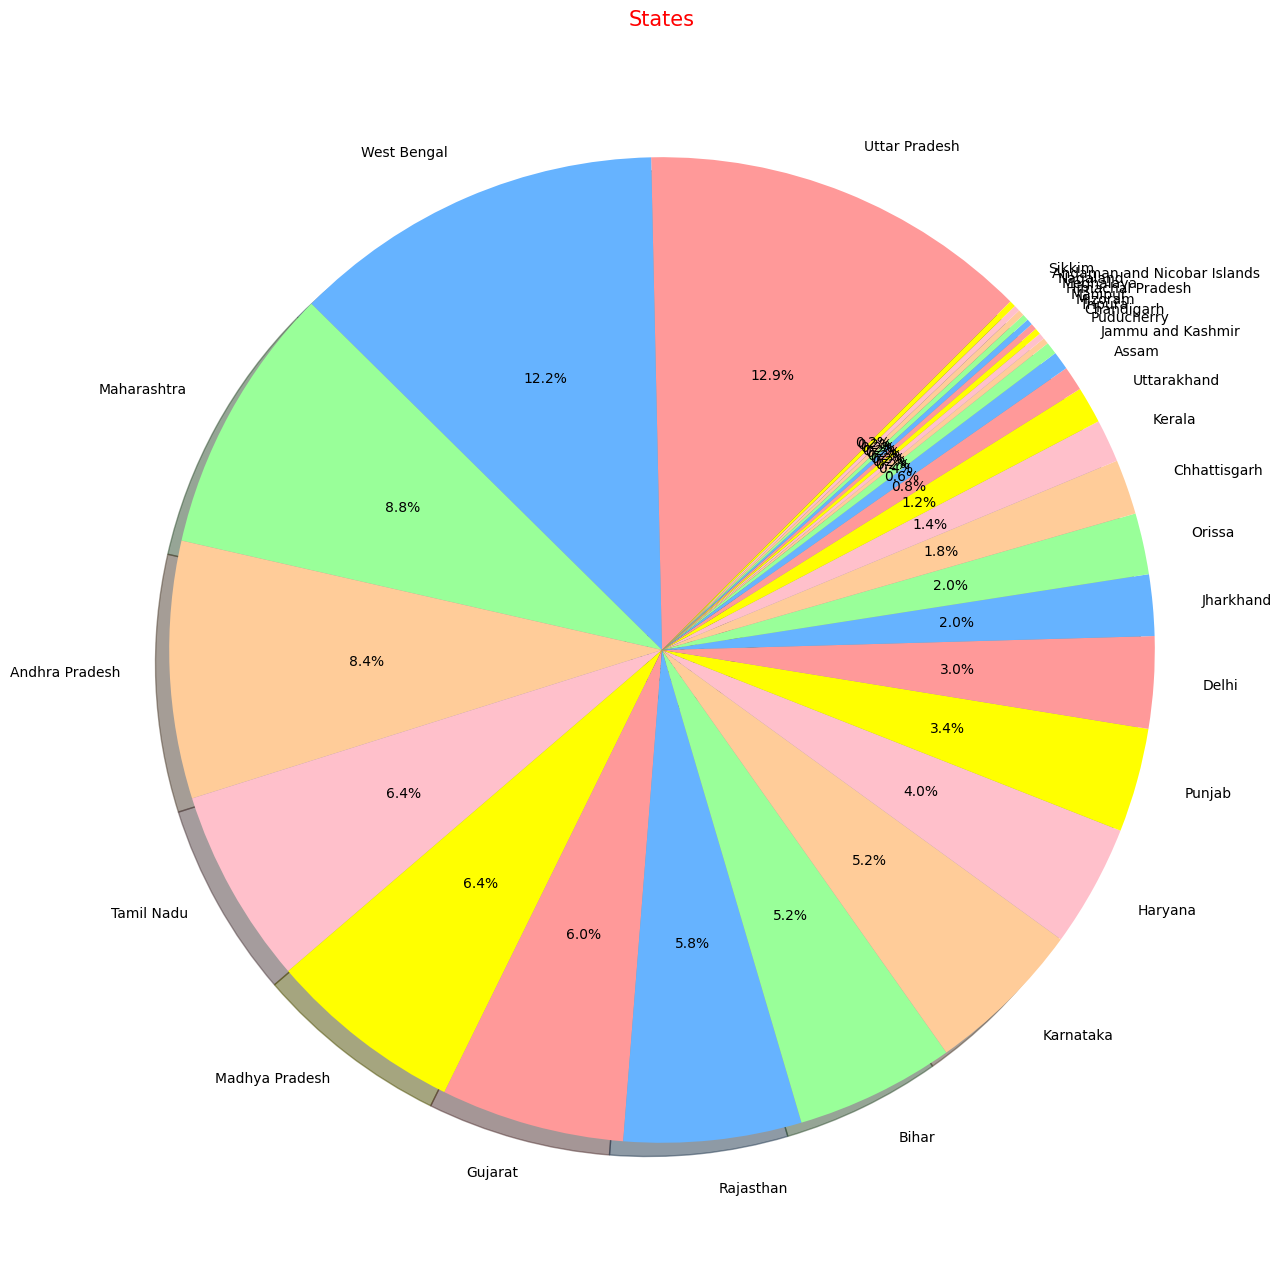

In [12]:
labels = data["State"].value_counts().index
sizes = data["State"].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"pink","yellow"]
plt.figure(figsize = (16,16))
plt.pie(sizes, labels=labels, rotatelabels=False, autopct='%1.1f%%',colors=colors,shadow=True, startangle=45)
plt.title('States',color = 'red',fontsize = 15)
plt.show()

Blok kode  diagram lingkaran tersebut memvisualisasikan distribusi kota-kota di berbagai negara bagian dalam DataFrame `data`. Berikut adalah rincian setiap baris:

*   **`labels = data["State"].value_counts().index`**:
    *   `data["State"]`: Memilih kolom 'State' dari DataFrame Anda.
    *   `.value_counts()`: Menghitung kemunculan setiap negara bagian yang unik, mengembalikan Series di mana indeksnya adalah nama negara bagian dan nilainya adalah jumlahnya.
    *   `.index`: Mengekstrak nama-nama negara bagian (indeks dari Series `value_counts()`) untuk digunakan sebagai label untuk irisan diagram lingkaran.

*   **`sizes = data["State"].value_counts()`**:
    *   Mirip dengan baris sebelumnya, ini menghitung jumlah kota untuk setiap negara bagian. Jumlah ini akan menentukan ukuran setiap irisan dalam diagram lingkaran.

*   **`colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"pink","yellow"]`**:
    *   Baris ini mendefinisikan daftar kode warna heksadesimal dan nama warna umum yang akan digunakan untuk irisan diagram lingkaran. Jika ada lebih banyak negara bagian daripada warna, warnanya akan berulang.

*   **`plt.figure(figsize = (16,16))`**:
    *   `plt.figure()`: Membuat gambar baru untuk plot.
    *   `figsize = (16,16)`: Mengatur ukuran gambar menjadi 16 inci kali 16 inci, membuat plot besar dan mudah dibaca.

*   **`plt.pie(sizes, labels=labels, rotatelabels=False, autopct='%1.1f%%',colors=colors,shadow=True, startangle=45)`**:
    *   `plt.pie()`: Ini adalah fungsi inti yang menghasilkan diagram lingkaran.
        *   `sizes`: Memberikan nilai-nilai yang menentukan ukuran setiap irisan (jumlah kota per negara bagian).
        *   `labels=labels`: Menetapkan nama-nama negara bagian sebagai label untuk setiap irisan.
        *   `rotatelabels=False`: Mencegah label berputar, menjaganya tetap horizontal.
        *   `autopct='%1.1f%%'`: Memformat nilai persentase yang ditampilkan pada setiap irisan. `%1.1f%%` berarti satu digit setelah titik desimal, diikuti dengan tanda persen.
        *   `colors=colors`: Menerapkan daftar warna yang telah ditentukan ke irisan.
        *   `shadow=True`: Menambahkan efek bayangan ke diagram lingkaran untuk tampilan 3D.
        *   `startangle=45`: Memutar awal irisan pertama sebesar 45 derajat berlawanan arah jarum jam dari sumbu x.

*   **`plt.title('States',color = 'red',fontsize = 15)`**:
    *   `plt.title()`: Mengatur judul diagram lingkaran menjadi 'States'.
        *   `color = 'red'`: Mengatur warna teks judul menjadi merah.
        *   `fontsize = 15`: Mengatur ukuran font judul menjadi 15.

*   **`plt.show()`**:
    *   Menampilkan diagram lingkaran yang dihasilkan.

In [17]:
fig = px.scatter(data, x='Population', y='Literacy', color='City', hover_name='City', title='Hubungan antara Populasi, Literasi, dan Kota')
fig.show()

diagram scater tersebut menjelaskan hubungan antara populasi literasi dengan kota yang ada di india

Adapun maksud dari kode diagram pencar Plotly Express yang diatas ialah:

*   **`fig = px.scatter(data, x='Population', y='Literacy', color='City', hover_name='City', title='Hubungan antara Populasi, Literasi, dan Kota')`**:
    *   `px.scatter()`: Ini adalah fungsi dari library `plotly.express` yang digunakan untuk membuat diagram pencar (scatter plot).
    *   `data`: Argumen ini menentukan DataFrame yang akan digunakan untuk plotting, yaitu `data` DataFrame Anda.
    *   `x='Population'`: Mengatur kolom 'Population' dari DataFrame sebagai sumbu horizontal (x-axis) diagram.
    *   `y='Literacy'`: Mengatur kolom 'Literacy' dari DataFrame sebagai sumbu vertikal (y-axis) diagram.
    *   `color='City'`: Menginstruksikan Plotly untuk mewarnai setiap titik data berdasarkan nilai unik di kolom 'City'. Ini membantu membedakan kota-kota yang berbeda dalam plot.
    *   `hover_name='City'`: Ketika Anda mengarahkan kursor ke titik mana pun di plot, nama kota (dari kolom 'City') akan ditampilkan sebagai informasi hover.
    *   `title='Hubungan antara Populasi, Literasi, dan Kota'`: Menetapkan judul untuk diagram pencar, yang menjelaskan tujuan plot ini.

*   **`fig.show()`**:
    *   Metode ini digunakan untuk menampilkan objek figur (`fig`) yang telah dibuat. Ini akan merender diagram pencar interaktif di output sel.

/tmp/ipykernel_1529/3782585681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x="State",palette="icefire")


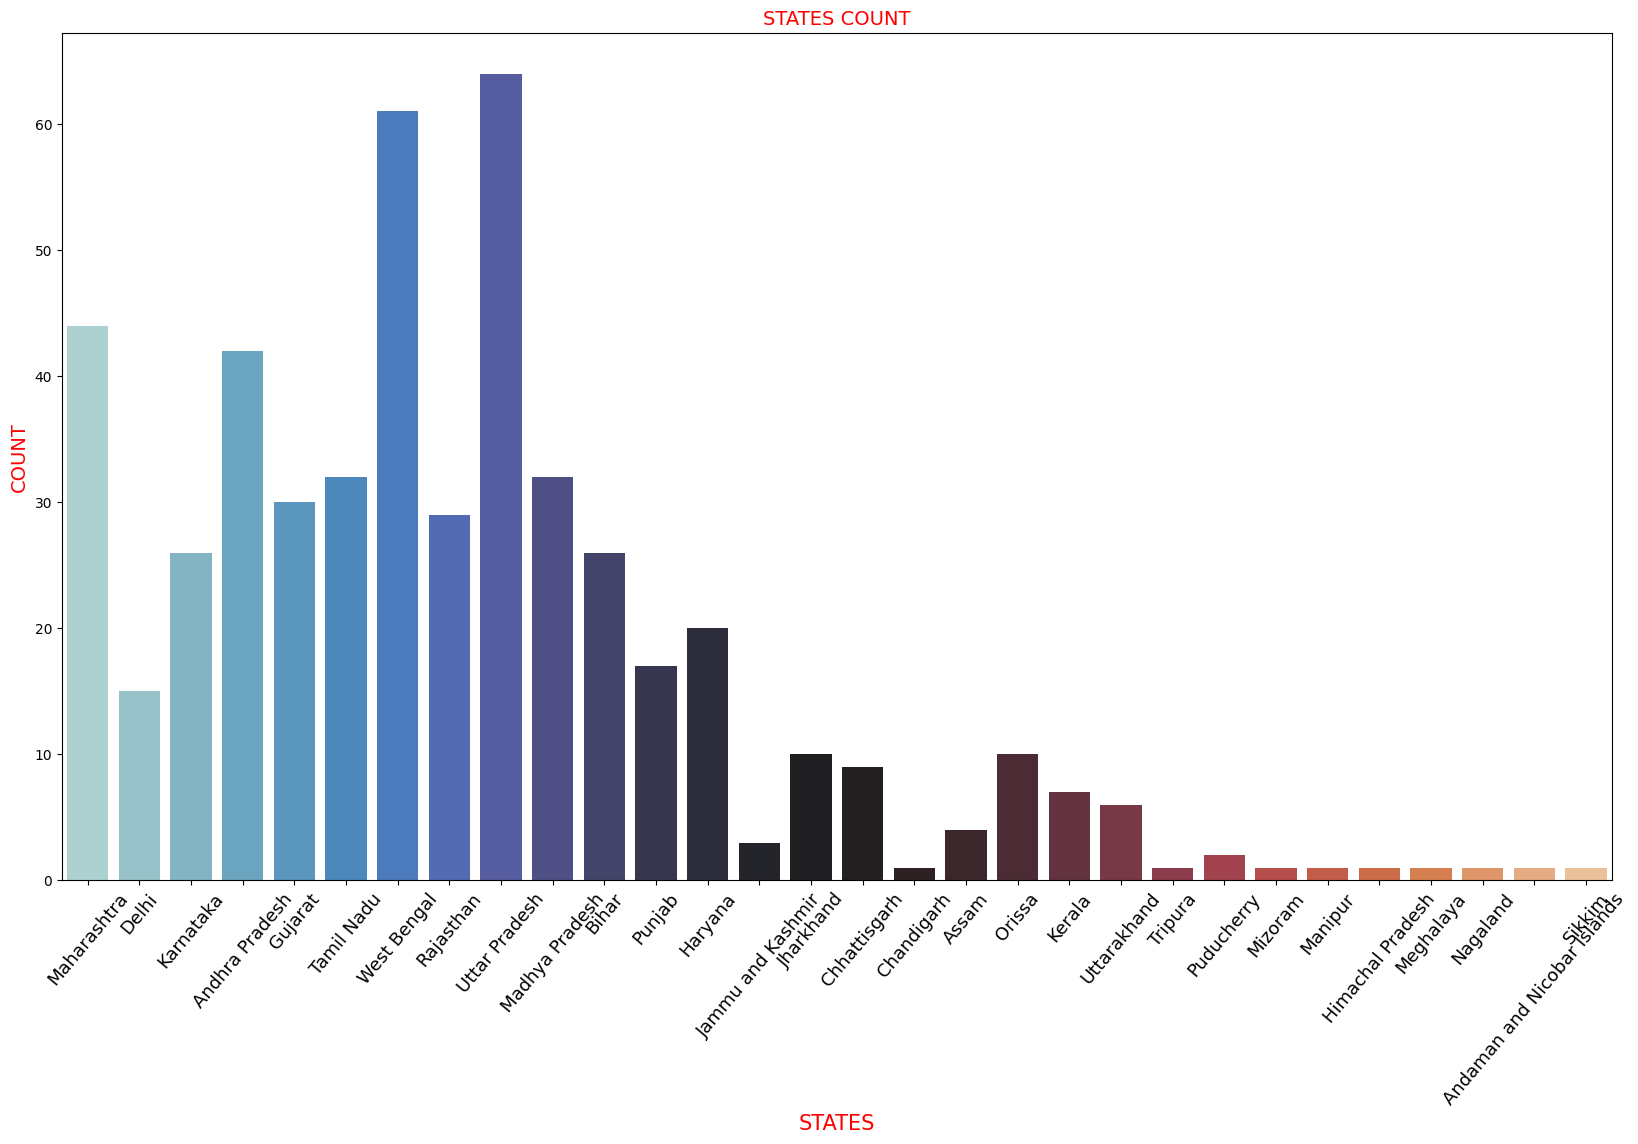

In [13]:
plt.figure(figsize=(20,11))
sns.countplot(data=data,x="State",palette="icefire")
plt.xticks(fontsize=13,rotation=50)
plt.xlabel("STATES",fontsize=15,color="RED")
plt.ylabel("COUNT",fontsize=14,color="RED")
plt.title("STATES COUNT",fontsize=14,color="RED")
plt.show()

Penjelasan dari setiap baris dalam blok kode yang digunakan untuk membuat `countplot` (diagram jumlah) untuk kolom 'State':

*   **`plt.figure(figsize=(20,11))`**:
    *   `plt.figure()`: Membuat objek figure (gambar) baru untuk plot.
    *   `figsize=(20,11)`: Mengatur ukuran figure menjadi 20 inci lebar dan 11 inci tinggi, membuat plot menjadi besar dan mudah dibaca.

*   **`sns.countplot(data=data,x="State",palette="icefire")`**:
    *   `sns.countplot()`: Ini adalah fungsi dari library Seaborn yang digunakan untuk menampilkan hitungan observasi di setiap kategori menggunakan bar.
    *   `data=data`: Menentukan DataFrame `data` sebagai sumber data untuk plot.
    *   `x="State"`: Menentukan kolom 'State' sebagai variabel kategorikal yang akan diplot pada sumbu x. Fungsi ini akan menghitung berapa kali setiap negara bagian muncul dalam DataFrame.
    *   `palette="icefire"`: Mengatur skema warna untuk bar-bar dalam plot. 'icefire' adalah salah satu palet warna yang tersedia di Seaborn.

*   **`plt.xticks(fontsize=13,rotation=50)`**:
    *   `plt.xticks()`: Mengatur properti tanda centang (ticks) pada sumbu x.
    *   `fontsize=13`: Mengatur ukuran font label tanda centang sumbu x menjadi 13.
    *   `rotation=50`: Memutar label tanda centang sumbu x sebesar 50 derajat untuk mencegah tumpang tindih, terutama jika ada banyak kategori.

*   **`plt.xlabel("STATES",fontsize=15,color="RED")`**:
    *   `plt.xlabel()`: Mengatur label untuk sumbu x.
    *   `"STATES"`: Teks label sumbu x.
    *   `fontsize=15`: Mengatur ukuran font label sumbu x menjadi 15.
    *   `color="RED"`: Mengatur warna teks label sumbu x menjadi merah.

*   **`plt.ylabel("COUNT",fontsize=14,color="RED")`**:
    *   `plt.ylabel()`: Mengatur label untuk sumbu y.
    *   `"COUNT"`: Teks label sumbu y.
    *   `fontsize=14`: Mengatur ukuran font label sumbu y menjadi 14.
    *   `color="RED"`: Mengatur warna teks label sumbu y menjadi merah.

*   **`plt.title("STATES COUNT",fontsize=14,color="RED")`**:
    *   `plt.title()`: Mengatur judul plot.
    *   `"STATES COUNT"`: Teks judul plot.
    *   `fontsize=14`: Mengatur ukuran font judul plot menjadi 14.
    *   `color="RED"`: Mengatur warna teks judul plot menjadi merah.

*   **`plt.show()`**:
    *   Menampilkan plot yang telah dibuat. Ini merender visualisasi `countplot` di output sel.